In [3]:
import sys
import os

# Point directly to project_root/envs/arm2.xml
project_root = os.path.abspath("..")
xml_path = os.path.join(project_root, "envs", "arm2.xml")

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from envs.reach_env import PlanarReachEnv

# Set random seed for reproducibility
np.random.seed(42)

# Instantiate environment
env = PlanarReachEnv(
    target_mode="random",
    model_path=xml_path
)
num_episodes = 5
horizon = 200

# Store reward trajectories: shape (num_episodes, horizon)
all_rewards = []

for ep in range(num_episodes):
    obs, info = env.reset(seed=ep)
    ep_rewards = []
    
    for t in range(horizon):
        # Sample random action (or use a fixed action sequence)
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        ep_rewards.append(reward)
        
    all_rewards.append(ep_rewards)

all_rewards = np.array(all_rewards) # Shape: (5, 200)
print(f"Collected {num_episodes} trajectories of length {horizon}.")

Collected 5 trajectories of length 200.


In [4]:
def compute_returns_to_go(rewards: np.ndarray, gamma: float) -> np.ndarray:
    """
    Computes discounted returns-to-go G_t for an episode reward sequence.
    
    Args:
        rewards: 1D array of shape (T,) containing step rewards R_t
        gamma: Discount factor in [0, 1)
        
    Returns:
        returns: 1D array of shape (T,) containing returns-to-go G_t
    """
    T = len(rewards)
    returns = np.zeros(T, dtype=np.float32)
    g = 0.0
    
    # Iterate backwards from final step T-1 down to 0
    for t in reversed(range(T)):
        g = rewards[t] + gamma * g
        returns[t] = g
        
    return returns

# Compute mean returns-to-go across episodes for gamma = 0.90 and gamma = 0.99
returns_gamma_090 = np.mean([compute_returns_to_go(ep_r, gamma=0.90) for ep_r in all_rewards], axis=0)
returns_gamma_099 = np.mean([compute_returns_to_go(ep_r, gamma=0.99) for ep_r in all_rewards], axis=0)
returns_undiscounted = np.mean([compute_returns_to_go(ep_r, gamma=1.00) for ep_r in all_rewards], axis=0)

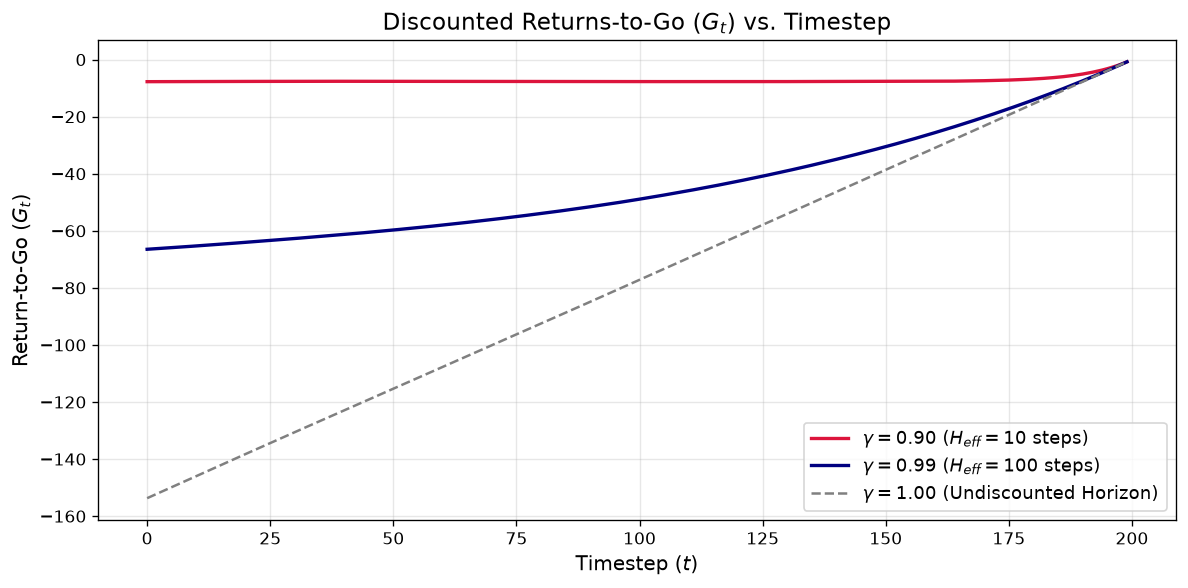

In [5]:
plt.figure(figsize=(10, 5), dpi=120)
timesteps = np.arange(horizon)

plt.plot(timesteps, returns_gamma_090, label=r"$\gamma = 0.90$ ($H_{eff} = 10$ steps)", linewidth=2, color='crimson')
plt.plot(timesteps, returns_gamma_099, label=r"$\gamma = 0.99$ ($H_{eff} = 100$ steps)", linewidth=2, color='navy')
plt.plot(timesteps, returns_undiscounted, label=r"$\gamma = 1.00$ (Undiscounted Horizon)", linestyle='--', linewidth=1.5, color='gray')

plt.title("Discounted Returns-to-Go ($G_t$) vs. Timestep", fontsize=14)
plt.xlabel("Timestep ($t$)", fontsize=12)
plt.ylabel("Return-to-Go ($G_t$)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()